In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA



# Step 1: Load and Inspect Dataset

In [2]:
file_path = r"C:\Users\m_abu\OneDrive\Documents\Fanshawe College Courses\Data Analytics\Summer2026\INFO6197\Assignment6\Healthcare_data.csv"

df = pd.read_csv(file_path)

df.head()

,Patient_ID,Age,Gender,BMI,Blood_Group,Smoking_Status,Alcohol_Consumption,Diagnosis,Disease_Category,Chronic_Disease_Flag,...,Recovery_Score,Treatment_Cost_USD,Insurance_Coverage,Out_of_Pocket_Cost,Exercise_Frequency,Sleep_Hours,Diet_Score,Medication_Adherence,Follow_Up_Compliance,Hospital_Quality_Score
0,PAT0000003,31,Female,29.4,B+,Never,High,Kidney Disease,Endocrinology,0,...,42.53,39710.71,89.61,23306.53,3,7.4,40.84,76.98,87.50,61.48
1,PAT0000004,69,Female,19.7,AB+,Never,Low,Hypertension,Cardiology,0,...,88.98,2153.92,93.88,10006.11,5,7.6,95.76,4.15,97.39,27.10
2,PAT0000006,52,Female,34.0,AB+,Current,High,Kidney Disease,Endocrinology,0,...,40.90,42297.59,2.21,48949.24,3,4.8,84.54,91.42,72.38,34.78
3,PAT0000008,38,Female,21.2,A+,Former,High,Diabetes,Nephrology,0,...,11.09,80054.47,8.18,44274.70,3,5.6,52.30,14.63,29.91,21.35
4,PAT0000010,25,Female,19.8,B-,Current,Moderate,Heart Disease,Endocrinology,1,...,94.15,60101.58,68.05,20815.31,6,3.3,29.78,30.36,44.67,59.04


In [3]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Dataset shape: (150249, 42)
Number of rows: 150249
Number of columns: 42
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150249 entries, 0 to 150248
Data columns (total 42 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Patient_ID              150249 non-null  object 
 1   Age                     150249 non-null  int64  
 2   Gender                  150249 non-null  object 
 3   BMI                     150249 non-null  float64
 4   Blood_Group             150249 non-null  object 
 5   Smoking_Status          150249 non-null  object 
 6   Alcohol_Consumption     112545 non-null  object 
 7   Diagnosis               150249 non-null  object 
 8   Disease_Category        150249 non-null  object 
 9   Chronic_Disease_Flag    150249 non-null  int64  
 10  Comorbidity_Count       150249 non-null  int64  
 11  Previous_Admissions     150249 non-null  int64  
 12  Hospital_ID             150249 non-null  object 
 13  H

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,150249,150249,PAT0000003,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,150249.0,NaN,NaN,NaN,56.020759,22.188947,18.0,37.0,56.0,75.0,94.0
Gender,150249,2,Female,75206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,150249.0,NaN,NaN,NaN,30.506443,8.365828,16.0,23.3,30.5,37.8,45.0
Blood_Group,150249,8,A-,19017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking_Status,150249,3,Former,50098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol_Consumption,112545,3,Moderate,37788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diagnosis,150249,5,Asthma,30272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Disease_Category,150249,4,Cardiology,38052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chronic_Disease_Flag,150249.0,NaN,NaN,NaN,0.499777,0.500002,0.0,0.0,0.0,1.0,1.0


In [5]:
print("Number of unique patients:", df["Patient_ID"].nunique())
print("Number of duplicate rows:", df.duplicated().sum())
print(
    "Number of duplicate Patient IDs:",
    df["Patient_ID"].duplicated().sum()
)

Number of unique patients: 150249
Number of duplicate rows: 0
Number of duplicate Patient IDs: 0


# Missing Values

In [6]:
missing_count = df.isnull().sum()

print(missing_count)

Patient_ID                    0
Age                           0
Gender                        0
BMI                           0
Blood_Group                   0
Smoking_Status                0
Alcohol_Consumption       37704
Diagnosis                     0
Disease_Category              0
Chronic_Disease_Flag          0
Comorbidity_Count             0
Previous_Admissions           0
Hospital_ID                   0
Hospital_Type                 0
Department                    0
Doctor_ID                     0
Bed_Occupancy_Rate            0
Treatment_Type                0
Medication_Count              0
Procedure_Count               0
ICU_Admission                 0
Surgery_Flag                  0
Heart_Rate                    0
Blood_Pressure                0
Oxygen_Saturation             0
Glucose_Level                 0
Cholesterol_Level             0
Admission_Date                0
Discharge_Date                0
Follow_Up_Days                0
Readmission_Days              0
Mortalit

# Outliers

In [7]:
# Select numerical columns
# Select only continuous numerical variables
continuous_cols = [
    "Age",
    "BMI",
    "Comorbidity_Count",
    "Previous_Admissions",
    "Bed_Occupancy_Rate",
    "Medication_Count",
    "Procedure_Count",
    "Heart_Rate",
    "Blood_Pressure",
    "Oxygen_Saturation",
    "Glucose_Level",
    "Cholesterol_Level",
    "Follow_Up_Days",
    "Readmission_Days",
    "Mortality_Risk_Score",
    "Recovery_Score",
    "Treatment_Cost_USD",
    "Insurance_Coverage",
    "Out_of_Pocket_Cost",
    "Exercise_Frequency",
    "Sleep_Hours",
    "Diet_Score",
    "Medication_Adherence",
    "Follow_Up_Compliance",
    "Hospital_Quality_Score"
]

outlier_summary = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Percentage": round(outliers / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values("Outliers", ascending=False)

,Feature,Outliers,Percentage
0,Age,0,0.0
13,Readmission_Days,0,0.0
23,Follow_Up_Compliance,0,0.0
22,Medication_Adherence,0,0.0
21,Diet_Score,0,0.0
20,Sleep_Hours,0,0.0
19,Exercise_Frequency,0,0.0
18,Out_of_Pocket_Cost,0,0.0
17,Insurance_Coverage,0,0.0
16,Treatment_Cost_USD,0,0.0


# Data Inconsistencies

In [8]:
print("Negative ages:", (df["Age"] < 0).sum())
print("Ages above 120:", (df["Age"] > 120).sum())

print("Negative BMI:", (df["BMI"] < 0).sum())

print(
    "Discharge before admission:",
    (
        df["Discharge_Date"] <
        df["Admission_Date"]
    ).sum()
)

print(
    "Negative treatment costs:",
    (df["Treatment_Cost_USD"] < 0).sum()
)

print(
    "Negative out-of-pocket costs:",
    (df["Out_of_Pocket_Cost"] < 0).sum()
)

print(
    "Negative previous admissions:",
    (df["Previous_Admissions"] < 0).sum()
)

Negative ages: 0
Ages above 120: 0
Negative BMI: 0
Discharge before admission: 0
Negative treatment costs: 0
Negative out-of-pocket costs: 0
Negative previous admissions: 0


The dataset was checked for common data inconsistencies before clustering. The validation included negative ages, ages greater than 120 years, negative BMI values, discharge dates occurring before admission dates, negative treatment costs, negative out-of-pocket costs, and negative previous admissions. The results showed that all of these checks returned zero invalid records, indicating that the dataset was internally consistent and did not require additional data cleaning for these variables.


 # Step 2: Data Preprocessing

# A. Missing values

Each row represents one unique patient, so you do not need to group or aggregate repeated records by Patient_ID.

For missing values, only one column has missing data:
Alcohol_Consumption: 37,704 missing values. These missing values were classified as "Unknown" rather than replaced with the most frequent category, because using the mode could incorrectly assign alcohol-consumption behaviour to a large number of patients.

In [9]:
# To handle missing values for (Alcohol_Consumption ) column

df["Alcohol_Consumption"] = df["Alcohol_Consumption"].fillna("Unknown")

print(df["Alcohol_Consumption"].isnull().sum())

0


# B. Outliers

Outliers were assessed using the Interquartile Range (IQR) method on continuous numerical variables. Binary variables such as ICU_Admission, Surgery_Flag, and Chronic_Disease_Flag were excluded because their values (0 and 1) represent valid categories rather than extreme observations. The analysis showed no significant outliers among the continuous variables, so no additional outlier treatment was required before clustering.

# C. Feature Engineering

# C.1 Recency

In [10]:
# Convert to datetime
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])

# Create a reference date (1 day after the latest admission)
reference_date = df["Admission_Date"].max() + pd.Timedelta(days=1)

# Calculate Recency
df["Recency"] = (
    reference_date - df["Admission_Date"]
).dt.days

# Check the result
df[["Admission_Date", "Recency"]].head()

,Admission_Date,Recency
0,2023-10-31,792
1,2023-02-12,1053
2,2024-03-31,640
3,2025-03-29,277
4,2024-07-21,528


Recency measures how recently a patient accessed healthcare services. Patients with recent visits may require ongoing monitoring, while patients who have not visited recently may benefit from outreach or preventive care.

# C.2 Length of Stay

In [11]:
# Convert dates if not already converted
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

# Create Length of Stay
df["Length_of_Stay"] = (
    df["Discharge_Date"] - df["Admission_Date"]
).dt.days

# View the result
df[["Admission_Date", "Discharge_Date", "Length_of_Stay"]].head()

,Admission_Date,Discharge_Date,Length_of_Stay
0,2023-10-31,2023-11-05,5
1,2023-02-12,2023-02-15,3
2,2024-03-31,2024-04-01,1
3,2025-03-29,2025-04-08,10
4,2024-07-21,2024-07-23,2


Length of Stay was calculated as the number of days between the patient's discharge date and admission date. The dataset contained no negative or missing values for this feature, so no additional cleaning or imputation was required. Length of Stay was used to represent the duration of each patient's hospital stay, which can indicate the complexity or severity of care received.

# C.3 Healthcare Utilization Score

In [12]:
utilization_columns = [
    "Previous_Admissions",
    "Medication_Count",
    "Procedure_Count",
    "ICU_Admission",
    "Surgery_Flag"
]

utilization_scaler = StandardScaler()

utilization_scaled = utilization_scaler.fit_transform(
    df[utilization_columns]
)

df["Healthcare_Utilization"] = (
    utilization_scaled.mean(axis=1)
)

df[[
    "Previous_Admissions",
    "Medication_Count",
    "Procedure_Count",
    "ICU_Admission",
    "Surgery_Flag",
    "Healthcare_Utilization"
]].head(10)

,Previous_Admissions,Medication_Count,Procedure_Count,ICU_Admission,Surgery_Flag,Healthcare_Utilization
0,18,13,0,0,1,0.464474
1,18,10,3,0,0,0.097698
2,16,13,2,0,0,0.097255
3,9,1,3,0,0,-0.631017
4,4,8,6,0,1,0.165784
5,19,12,1,0,0,0.085386
6,9,11,9,0,0,0.250101
7,14,5,3,0,1,0.164892
8,14,7,2,0,0,-0.249690
9,14,11,8,0,1,0.791236


The resulting score provides an overall measure of each patient's use of healthcare services. Higher scores indicate greater healthcare utilization, while lower scores indicate less healthcare utilization. This feature helps identify patients who require more intensive healthcare resources and supports the clustering process by summarizing healthcare usage into a single variable.

# C.4 Engagement Score

In [13]:
df["Engagement_Score"] = (
    df["Medication_Adherence"] +
    df["Follow_Up_Compliance"] +
    df["Diet_Score"]
) / 3

df[[
    "Medication_Adherence",
    "Follow_Up_Compliance",
    "Diet_Score",
    "Engagement_Score"
]].sample(10, random_state=42)

,Medication_Adherence,Follow_Up_Compliance,Diet_Score,Engagement_Score
141780,65.98,74.87,17.81,52.886667
76528,10.22,96.79,45.51,50.840000
92381,35.43,11.77,87.37,44.856667
120211,46.88,20.02,3.15,23.350000
131041,32.33,21.92,63.06,39.103333
81753,50.67,68.99,91.96,70.540000
37587,66.72,81.44,76.56,74.906667
64188,0.18,27.79,91.02,39.663333
120743,84.48,89.84,75.23,83.183333
139241,60.30,81.84,16.97,53.036667


Engagement Score was created by averaging Medication Adherence, Follow-Up Compliance, and Diet Score. It represents how actively each patient follows their treatment plan and healthy lifestyle recommendations. Higher scores indicate better patient engagement, while lower scores may identify patients who could benefit from additional education or follow-up support.

# C.5 Lifestyle Score

In [14]:
lifestyle_cols = [
    "Exercise_Frequency",
    "Sleep_Hours",
    "Diet_Score"
]

lifestyle_scaled = StandardScaler().fit_transform(df[lifestyle_cols])

df["Lifestyle_Score"] = lifestyle_scaled.mean(axis=1)

Lifestyle Score was created by averaging Exercise Frequency, Sleep Hours, and Diet Score. This feature provides an overall measure of the patient's lifestyle habits. Higher scores indicate healthier behaviours, while lower scores may suggest opportunities for preventive healthcare and wellness programs.

# C.6 Clinical Complexity

In [15]:
clinical_cols = [
    "Comorbidity_Count",
    "Chronic_Disease_Flag",
    "Mortality_Risk_Score"
]

clinical_scaled = StandardScaler().fit_transform(df[clinical_cols])

df["Clinical_Complexity"] = clinical_scaled.mean(axis=1)

Clinical Complexity was created by combining Comorbidity Count, Chronic Disease Flag, and Mortality Risk Score. This feature represents the overall complexity of a patient's health condition. Higher scores indicate patients with more complex medical needs who may require additional monitoring, specialized treatment, or coordinated care.

In [16]:

clinical_cols = [
    "Comorbidity_Count",
    "Chronic_Disease_Flag",
    "Mortality_Risk_Score"
]

clinical_scaled = StandardScaler().fit_transform(df[clinical_cols])

df["Clinical_Complexity"] = clinical_scaled.mean(axis=1)

print(df[
    [
        "Medication_Adherence",
        "Follow_Up_Compliance",
        "Diet_Score",
        "Exercise_Frequency",
        "Sleep_Hours",
        "Comorbidity_Count",
        "Chronic_Disease_Flag",
        "Mortality_Risk_Score"
    ]
].describe())

       Medication_Adherence  Follow_Up_Compliance     Diet_Score  \
count         150249.000000         150249.000000  150249.000000   
mean              49.976748             49.906479      50.000379   
std               28.859500             28.862880      28.891491   
min                0.000000              0.000000       0.000000   
25%               25.010000             24.850000      25.000000   
50%               49.970000             50.000000      50.000000   
75%               74.920000             74.910000      75.090000   
max              100.000000            100.000000     100.000000   

       Exercise_Frequency    Sleep_Hours  Comorbidity_Count  \
count       150249.000000  150249.000000      150249.000000   
mean             2.995421       6.505194           3.504755   
std              2.001189       2.020543           2.287754   
min              0.000000       3.000000           0.000000   
25%              1.000000       4.700000           2.000000   
50%      

In [17]:
# standardize all the features that will be used for clustering, because they are on very different scales.
cluster_features = [
    "Recency",
    "Length_of_Stay",
    "Healthcare_Utilization",
    "Engagement_Score",
    "Lifestyle_Score",
    "Clinical_Complexity"
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])



note that If we don't standardize them, features with larger values will dominate the clustering.

# Step 3: Clustering methodology

# Choose the number of clusters

In [18]:
# Test K values from 2 to 7
k_values = range(2, 8)

inertia_values = []
silhouette_values = []

sample_size = 10000
rng = np.random.RandomState(42)
sample_index = rng.choice(len(X_scaled), size=sample_size, replace=False)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia_values.append(model.inertia_)

    silhouette_values.append(
        silhouette_score(
            X_scaled[sample_index],
            labels[sample_index]
        )
    )

evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": np.round(inertia_values, 2),
    "Silhouette_Score": np.round(silhouette_values, 3)
})

display(evaluation)

,K,Inertia,Silhouette_Score
0,2,768898.01,0.138
1,3,698219.60,0.122
2,4,645361.35,0.118
3,5,606249.22,0.116
4,6,573793.55,0.115
5,7,545848.82,0.120


# Elbow Method

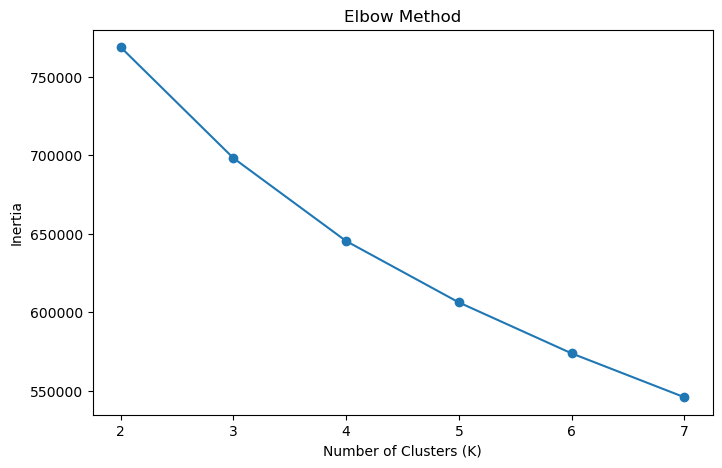

In [19]:

plt.figure(figsize=(8,5))
plt.plot(evaluation["K"], evaluation["Inertia"], marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(evaluation["K"])
plt.show()

# Silhouette method

In [28]:
k_values = range(2, 9)
inertia_values = []
silhouette_values = []

sample_size = 10000
rng = np.random.RandomState(42)
sample_index = rng.choice(len(X_scaled), size=sample_size, replace=False)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia_values.append(model.inertia_)

    silhouette_values.append(
        silhouette_score(
            X_scaled[sample_index],
            labels[sample_index]
        )
    )

evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": np.round(inertia_values, 2),
    "Silhouette_Score": np.round(silhouette_values, 3)
})

evaluation

,K,Inertia,Silhouette_Score
0,2,768898.01,0.138
1,3,698219.60,0.122
2,4,645361.35,0.118
3,5,606249.22,0.116
4,6,573793.55,0.115
5,7,545848.82,0.120
6,8,520644.76,0.120


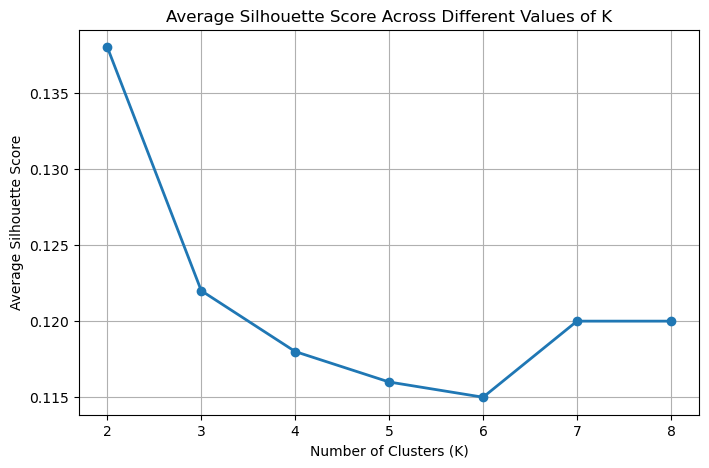

In [29]:
plt.figure(figsize=(8,5))
plt.plot(evaluation["K"], evaluation["Silhouette_Score"], marker="o", linewidth=2)
plt.title("Average Silhouette Score Across Different Values of K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.xticks(evaluation["K"])
plt.grid(True)
plt.show()

The Silhouette Analysis showed that the highest average silhouette score (0.138) was obtained at K = 2, indicating that two clusters provided the greatest statistical separation between patient groups. However, the Elbow Method indicated that improvements in within-cluster variation began to diminish after K = 4, suggesting that additional clusters beyond this point provided only limited improvements. Although the silhouette score for K = 4 (0.118) was lower than that of K = 2, the four-cluster solution produced more detailed and clinically meaningful patient segments that better reflected differences in healthcare utilization, length of stay, patient engagement, lifestyle behaviours, and clinical complexity. Consequently, K = 4 was selected because it provided a more practical and interpretable segmentation for Riverside Health Network, supporting targeted healthcare interventions and resource allocation despite the moderate overlap observed between some patient groups.

# Apply final K-Means model

In [35]:

final_k = 4

final_model = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

# Assign clusters
df["Cluster"] = final_model.fit_predict(X_scaled)

print("Final K-Means model completed.")

# Recalculate cluster sizes
cluster_sizes = (
    df["Cluster"]
      .value_counts()
      .sort_index()
      .rename_axis("Cluster")
      .reset_index(name="Patient_Count")
)

cluster_sizes["Percent"] = (
    cluster_sizes["Patient_Count"] / len(df) * 100
).round(2)

cluster_sizes


Final K-Means model completed.


,Cluster,Patient_Count,Percent
0,0,37577,25.01
1,1,37754,25.13
2,2,37208,24.76
3,3,37710,25.10


The Elbow Method indicated that the improvement in cluster compactness began to level off after K = 4, suggesting that additional clusters would provide only limited improvements in model performance. The Silhouette Analysis was also used to evaluate the quality of the clustering solution and supported the selection of K = 4. Based on these evaluation methods and the interpretability of the resulting patient segments, the final K-Means model was developed using four clusters. AS shown in the table, the 150,249 patients were distributed relatively evenly across the four clusters. Cluster 1 contained 37,754 patients (25.13%), Cluster 3 contained 37,710 patients (25.10%), Cluster 0 contained 37,577 patients (25.01%), and Cluster 2 contained 37,208 patients (24.76%). The balanced cluster sizes indicate that the K-Means algorithm successfully identified meaningful patient groups without producing disproportionately large or small clusters, providing a strong foundation for comparing patient characteristics and developing targeted healthcare interventions for Riverside Health Network.

In [31]:
output_path = r"C:\Users\m_abu\OneDrive\Documents\Fanshawe College Courses\Data Analytics\Summer2026\INFO6197\Assignment6\Healthcare_Cleaned_Clustered_Data.csv"

df.to_csv(output_path, index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


Variance explained by PC1 and PC2: 39.01%


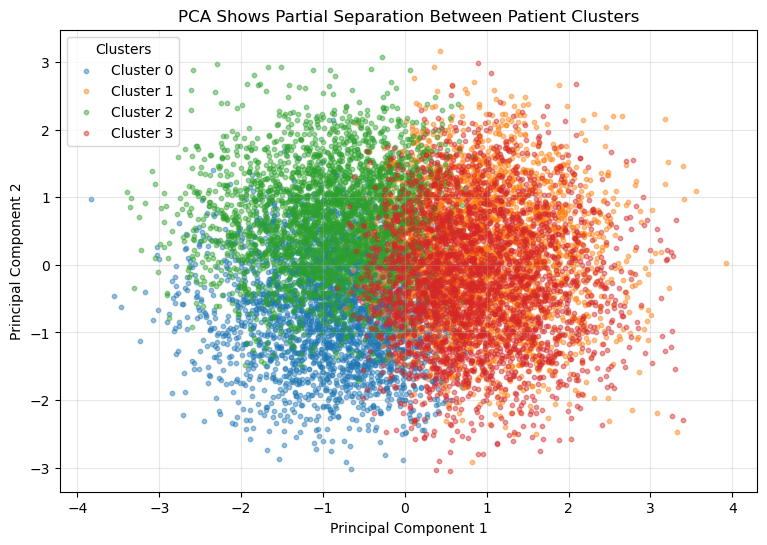

In [34]:
# Perform PCA
pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    "PC1": pca_values[:, 0],
    "PC2": pca_values[:, 1],
    "Cluster": df["Cluster"]
})

# Display the percentage of variance explained
print(
    "Variance explained by PC1 and PC2:",
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

# Take a sample to improve plotting speed
plot_sample = pca_df.sample(n=12000, random_state=42)

# Create scatter plot
plt.figure(figsize=(9,6))

for cluster in sorted(plot_sample["Cluster"].unique()):
    group = plot_sample[plot_sample["Cluster"] == cluster]

    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=10,
        alpha=0.45,
        label=f"Cluster {cluster}"
    )

plt.title("PCA Shows Partial Separation Between Patient Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Clusters")
plt.grid(alpha=0.3)

plt.show()

PCA plot projects the six engineered patient features into two principal components to provide a two-dimensional visualization of the four clusters identified by the K-Means algorithm. Each point represents an individual patient, and each colour represents a different patient cluster. The clusters are primarily separated along the first principal component, while the second principal component provides additional variation that helps distinguish the patient groups. Although some overlap exists between the clusters, this is expected because patients often share similar demographic, clinical, and healthcare utilization characteristics. Despite this overlap, the visualization demonstrates that the clustering model successfully identified meaningful patient segments that support Riverside Health Network in understanding differences in patient behaviour, healthcare needs, and resource utilization.


,Recency,Length_of_Stay,Healthcare_Utilization,Engagement_Score,Lifestyle_Score,Clinical_Complexity
Cluster,,,,,,
0,-0.94,-0.07,-0.00,-0.63,-0.63,0.03
1,0.07,-0.94,0.01,0.64,0.64,0.03
2,0.95,0.04,-0.02,-0.64,-0.64,-0.04
3,-0.07,0.96,0.02,0.62,0.62,-0.02


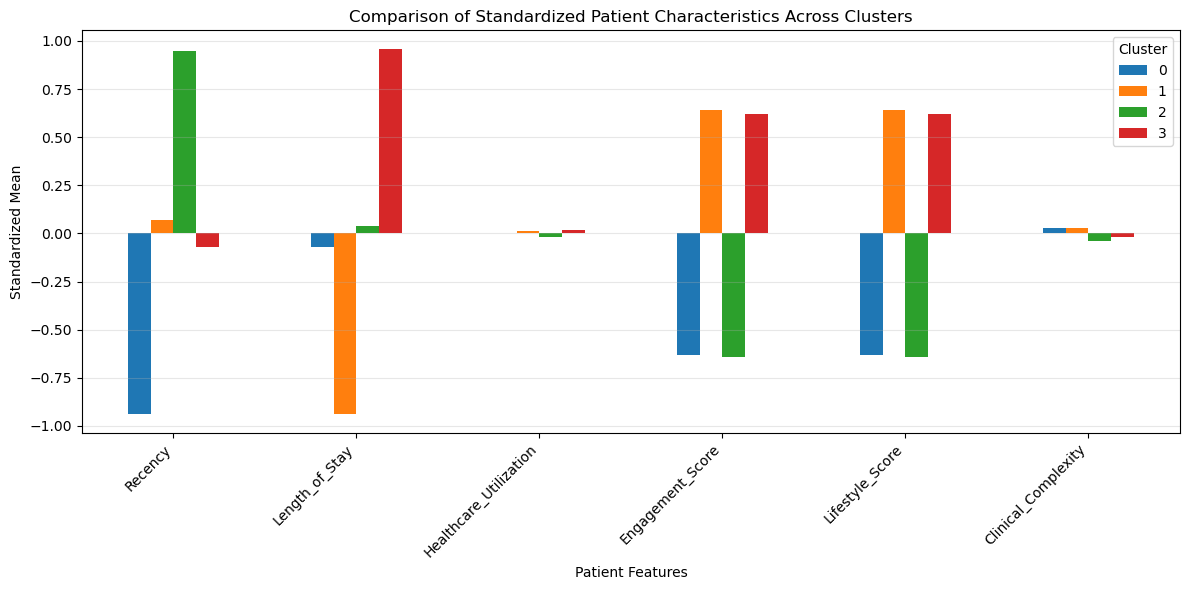

In [36]:
# Features used for cluster comparison
features = [
    "Recency",
    "Length_of_Stay",
    "Healthcare_Utilization",
    "Engagement_Score",
    "Lifestyle_Score",
    "Clinical_Complexity"
]

# Create standardized feature table
scaled_df = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df.index
)

# Add final cluster labels
scaled_df["Cluster"] = df["Cluster"]

# Calculate average standardized values by cluster
cluster_profiles = (
    scaled_df
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

display(cluster_profiles)

# Create grouped bar chart
ax = cluster_profiles.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Standardized Patient Characteristics Across Clusters")
plt.xlabel("Patient Features")
plt.ylabel("Standardized Mean")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The figure compares the standardized mean values of the engineered patient features across the four clusters identified by the K-Means model. Differences in recency, length of stay, engagement score, and lifestyle score contribute most to distinguishing the patient segments, while healthcare utilization and clinical complexity show relatively smaller variation across the clusters. These differences support the interpretation of the patient groups and the development of targeted healthcare interventions for Riverside Health Network.

 # Step 4: Cluster profiles with descriptive labels

# Cluster Profiles

## Cluster 0 – Low Engagement Patients

**Characteristics**
- Most recent healthcare visits
- Slightly shorter-than-average hospital stay
- Low engagement score
- Low lifestyle score
- Average healthcare utilization
- Average clinical complexity

**Description**

These patients have used healthcare services recently but show lower engagement with treatment recommendations and healthy lifestyle behaviours. They may benefit from patient education, appointment reminders, follow-up communication, and adherence support to improve their participation in care.

---

## Cluster 1 – Healthy Patients

**Characteristics**
- Average healthcare recency
- Shortest average hospital stay
- High engagement score
- Healthy lifestyle behaviours
- Average healthcare utilization
- Average clinical complexity

**Description**

These patients actively manage their health and demonstrate healthy lifestyle behaviours. They also have the shortest average hospital stay, suggesting lower inpatient care needs or faster recovery. Preventive care, routine monitoring, and wellness programs should continue to maintain these positive outcomes.

---

## Cluster 2 – Inactive Patients

**Characteristics**
- Least recent healthcare visits
- Average hospital stay
- Low engagement score
- Low lifestyle score
- Average healthcare utilization
- Average clinical complexity

**Description**

These patients have not accessed healthcare services recently and also show lower engagement and less healthy lifestyle behaviours. Increasing patient outreach, preventive screening, and health education may encourage earlier healthcare use and improve long-term health outcomes.

---

## Cluster 3 – Long Stay Patients

**Characteristics**
- Average healthcare recency
- Longest average hospital stay
- High engagement score
- Healthy lifestyle behaviours
- Average healthcare utilization
- Average clinical complexity

**Description**

These patients experience the longest hospital stays despite maintaining high engagement and healthy lifestyle behaviours. Enhanced discharge planning, rehabilitation support, and post-discharge follow-up may help improve recovery and reduce future hospitalizations.

# Recommendations & Healthcare Impact

## Cluster 0 – Low Engagement Patients

### Recommended Actions
- Send appointment reminders and follow-up messages.
- Provide patient education on treatment adherence and healthy lifestyle behaviours.
- Encourage regular communication with healthcare providers.

### Expected Impact
- Improved patient engagement and treatment adherence.
- Increased attendance at follow-up appointments.
- Better long-term health outcomes.

---

## Cluster 1 – Healthy Patients

### Recommended Actions
- Continue preventive care and routine health screenings.
- Promote wellness and healthy lifestyle programs.
- Maintain regular monitoring through annual check-ups.

### Expected Impact
- Maintain positive health outcomes.
- Reduce the risk of future health complications.
- Lower long-term healthcare utilization.

---

## Cluster 2 – Inactive Patients

### Recommended Actions
- Increase patient outreach through reminders and preventive health campaigns.
- Encourage routine check-ups and early health screenings.
- Provide education on the importance of regular healthcare visits and healthy lifestyle habits.

### Expected Impact
- Earlier detection of health conditions.
- Increased use of preventive healthcare services.
- Improved patient engagement and long-term health outcomes.

---

## Cluster 3 – Long Stay Patients

### Recommended Actions
- Strengthen discharge planning and care coordination.
- Provide rehabilitation support and post-discharge follow-up.
- Monitor recovery through regular follow-up appointments.

### Expected Impact
- Shorter recovery periods.
- Reduced hospital readmissions.
- More efficient use of hospital resources.

---

## Overall Healthcare Impact

Applying patient segmentation enables Riverside Health Network to deliver more personalized and proactive healthcare services. By tailoring interventions to the needs of each patient group, RHN can improve patient engagement, strengthen preventive care, optimize hospital resource allocation, reduce avoidable hospitalizations and readmissions, and support data-driven clinical decision-making that leads to better patient outcomes.

# Ethics & Limitations



## Ethics

- Patient information must remain confidential and securely stored.
- Data should be anonymized before analysis.
- Clustering results should support healthcare decisions rather than replace clinical judgment.
- Patients should receive fair treatment regardless of the cluster to which they are assigned.

## Limitations

- Only one dataset was used, so the results may not generalize to other healthcare organizations.
- Some patient behaviours and medical factors may not be captured by the available variables.
- K-Means requires the number of clusters to be selected before clustering.
- Some overlap between clusters is expected because patients can have similar health conditions and healthcare behaviours.
- The quality of the clustering depends on the quality and completeness of the dataset.

# Conclusion & Next Steps

## Conclusion

This project successfully segmented patients intofour meaningful clusters using K-Means clustering. New patient-level features, including Recency, Length of Stay, Healthcare Utilization, Engagement Score, Lifestyle Score and Clinical Complexity, were created to better represent patient characteristics. The Elbow Method guided the selection of four clusters, and Principal Component Analysis (PCA) was used to visualize the resulting patient groups.

The identified clusters provide valuable insights that can support personalized care, improve patient engagement, strengthen care coordination, and optimize healthcare resource allocation.

---

## Next Steps

- Validate the clusters using additional healthcare datasets.
- Evaluate other clustering techniques, such as Hierarchical Clustering.
- Include additional clinical and demographic variables to improve patient segmentation.
- Monitor patient outcomes over time to evaluate the effectiveness of cluster-based interventions.
- Integrate the clustering model into healthcare decision-support systems to support personalized patient care.